# Step 11 – XGBoost + SHAP Interpretable Modelling

This notebook complements Step 10's parametric regressions with a **non-linear,
tree-based method** (XGBoost) and SHAP (SHapley Additive exPlanations) for interpretability.

**Division of labour with Step 10:**
- **Step 10** = all linear/parametric methods (OLS, Logit, Beta, Ridge, Lasso) → inference + robustness
- **Step 11** = XGBoost regression + SHAP → non-linearity testing + explainability for adoption *speed* at the **city–project event** level

**Model D-reg:**

| Model | DV | Method | Level | n | Features |
|---|---|---|---|---|---|
| D-reg | `log1p(lag)` | XGBRegressor | **City–project event** (each row = one city adopting one project) | ~25,000 | 11 city + 2 project-aggregate + 4 project attributes |

The model operates at the **event level**: each observation is one adoption event,
so **project-level attributes** (stars, forks, popularity percentile, etc.) vary
across rows; pure city-level scalars alone explain little variance in lag.
City-level regressions (n = 148) remain in Step 10 (see Section 10.5d).


In [1]:
import warnings

warnings.filterwarnings('ignore')



import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

import shap

from xgboost import XGBRegressor

from sklearn.model_selection import cross_val_score, StratifiedKFold, KFold

from sklearn.metrics import (roc_auc_score, f1_score, classification_report,

                             mean_squared_error, r2_score)

from sklearn.preprocessing import StandardScaler

from pathlib import Path



sns.set_theme(style='whitegrid', context='notebook')

plt.rcParams.update({'figure.dpi': 120})



DATA = Path('..') / 'data' / 'output'

city_attr = pd.read_csv(DATA / 'city_attributes.csv')

adoption  = pd.read_csv(DATA / 'city_project_adoption_events.csv')

prom = pd.read_csv(DATA.parent / 'processed' / 'prominent_projects_master.csv')

print(f'city_attributes: {city_attr.shape}')

print(f'adoption_events: {adoption.shape}')

print(f'prominent_projects: {prom.shape}')

city_attributes: (148, 28)
adoption_events: (39158, 6)
prominent_projects: (23481, 15)


In [2]:
# Prepare features: city (Step 10 IV + extras), project aggregates, project attributes

IV_COLS = ['log_degree', 'log_population', 'log_gdp', 'log_entity',

           'education_tertiary_pct', 'internet_users_pct',

           'rd_expenditure_pct', 'research_capacity', 'betweenness']



df_city = city_attr[city_attr['adoption_count'] > 0].copy()

df_city['originator_share'] = df_city['origination_count'] / df_city['adoption_count']

df_city['log_adoption'] = np.log1p(df_city['adoption_count'])

df_city['log_degree'] = np.log1p(df_city['weighted_degree'])

df_city['log_population'] = np.log1p(df_city['population_million'])

df_city['log_gdp'] = np.log(df_city['gdp_per_capita'])

df_city['log_entity'] = np.log1p(df_city['entity_count'])



EXTRA_CITY_COLS = ['eigenvector_centrality', 'origination_rate']
ALL_CITY_COLS = IV_COLS + EXTRA_CITY_COLS

df_cp = adoption.merge(df_city[['city'] + ALL_CITY_COLS], on='city', how='inner')

df_cp = df_cp.dropna(subset=IV_COLS + ['is_originator']).reset_index(drop=True)



proj_stats = adoption.groupby('project_id').agg(

    proj_n_cities=('city', 'nunique'),

).reset_index()

df_cp = df_cp.merge(proj_stats, on='project_id', how='left')

df_cp['log_proj_pop'] = np.log1p(df_cp['proj_n_cities'])



def _ym_to_months(ym):

    y, m = divmod(int(ym), 100)

    return (y - 2022) * 12 + (m - 1)

df_cp['proj_origin_idx'] = df_cp['global_origin_month'].apply(_ym_to_months)



# Project-level attributes (vary by event — unlike city-only scalars)

prom['metric_stars'] = pd.to_numeric(prom['metric_stars'], errors='coerce')

prom['metric_forks'] = pd.to_numeric(prom['metric_forks'], errors='coerce')

prom['metric_downloads'] = pd.to_numeric(prom['metric_downloads'], errors='coerce')

gh = prom[prom['platform'] == 'GitHub'].copy()

hf = prom[prom['platform'] == 'HuggingFace'].copy()

gh['popularity_pctile'] = gh['metric_stars'].rank(pct=True)

hf['popularity_pctile'] = hf['metric_downloads'].rank(pct=True)

gh['fork_star_ratio'] = gh['metric_forks'] / gh['metric_stars'].replace(0, np.nan)

proj_feats = pd.concat([

    gh[['full_id', 'metric_stars', 'metric_forks', 'popularity_pctile', 'fork_star_ratio']],

    hf[['full_id', 'popularity_pctile']],

]).rename(columns={'full_id': 'project_id'})

proj_feats['log_stars'] = np.log1p(proj_feats['metric_stars'])

proj_feats['log_forks'] = np.log1p(proj_feats['metric_forks'])

df_cp = df_cp.merge(

    proj_feats[['project_id', 'log_stars', 'log_forks',

                'popularity_pctile', 'fork_star_ratio']],

    on='project_id', how='left')



PROJ_ATTR_COLS = ['log_stars', 'log_forks', 'popularity_pctile', 'fork_star_ratio']

DREG_COLS = (IV_COLS + EXTRA_CITY_COLS

             + ['log_proj_pop', 'proj_origin_idx']

             + PROJ_ATTR_COLS)



df_lag = df_cp[df_cp['lag'] > 0].copy()

for c in PROJ_ATTR_COLS:

    df_lag[c] = df_lag[c].fillna(df_lag[c].median())



print(f'City-level observations:    {len(df_city)}')

print(f'City–project events (lag>0): {len(df_lag)}')

print(f'D-reg features ({len(DREG_COLS)}): city-base {len(IV_COLS)}, '

      f'city-extra {len(EXTRA_CITY_COLS)}, proj-agg 2, proj-attr {len(PROJ_ATTR_COLS)}')

print(f'  {DREG_COLS}')



City-level observations:    148
City–project events (lag>0): 25297
D-reg features (17): city-base 9, city-extra 2, proj-agg 2, proj-attr 4
  ['log_degree', 'log_population', 'log_gdp', 'log_entity', 'education_tertiary_pct', 'internet_users_pct', 'rd_expenditure_pct', 'research_capacity', 'betweenness', 'eigenvector_centrality', 'origination_rate', 'log_proj_pop', 'proj_origin_idx', 'log_stars', 'log_forks', 'popularity_pctile', 'fork_star_ratio']


---
## 11.1 – Model D-reg: Adoption Speed Regression (Event-Level)

**Research question:** How do **city characteristics** and **project characteristics**
jointly relate to adoption *speed* (`log1p(lag)`), at the **city–project event** level
(non-originator events only, `lag > 0`)?

**Specification:**
- **DV:** `log1p(lag)` (months from global project origin to city's first adoption).
- **City block (11):** same socioeconomic + network IVs as Step 10, plus
  `eigenvector_centrality` and `origination_rate`.
- **Project aggregates (2):** `log_proj_pop` (number of adopting cities),
  `proj_origin_idx` (project creation time trend).
- **Project attributes (4, event-varying):** `log_stars`, `log_forks`,
  `popularity_pctile`, `fork_star_ratio` (from `prominent_projects_master.csv`).

**Model:** `XGBRegressor` with tuned hyperparameters
(`n_estimators=1000`, `max_depth=6`, `learning_rate=0.03`, row/column subsampling 0.8),
5-fold CV R² reported on `log1p(lag)`.

**SHAP:** `shap.TreeExplainer` on the fitted booster — same interpretability workflow
as with sklearn `GradientBoostingRegressor`.

Each row is one adoption *event*; project attributes vary across rows, which is essential
for explanatory power at this level (pure city-level scalars alone plateau near R² ≈ 0.02).


Non-originator adoption events (lag > 0): 25297
Lag (raw):  mean=9.77, median=7, std=9.25, skew=1.36
Lag (log):  mean=2.01, std=0.88, skew=0.03

Features (17): ['log_degree', 'log_population', 'log_gdp', 'log_entity', 'education_tertiary_pct', 'internet_users_pct', 'rd_expenditure_pct', 'research_capacity', 'betweenness', 'eigenvector_centrality', 'origination_rate', 'log_proj_pop', 'proj_origin_idx', 'log_stars', 'log_forks', 'popularity_pctile', 'fork_star_ratio']



Model D-reg CV R² (log-lag, XGBoost): 0.3023 ± 0.0160
  Fold 1: R² = 0.3334
  Fold 2: R² = 0.2899
  Fold 3: R² = 0.2908
  Fold 4: R² = 0.2972
  Fold 5: R² = 0.3002



Full-data R² (log-lag)  = 0.5563
Full-data RMSE (log-lag) = 0.5846
Full-data R² (raw lag)  = 0.4560
Full-data RMSE (raw lag) = 6.83 months



SHAP feature importance (Model D-reg):
  proj_origin_idx                 mean|SHAP| = 0.2295
  log_proj_pop                    mean|SHAP| = 0.1198
  log_forks                       mean|SHAP| = 0.0719
  fork_star_ratio                 mean|SHAP| = 0.0667
  popularity_pctile               mean|SHAP| = 0.0662
  log_stars                       mean|SHAP| = 0.0524
  log_population                  mean|SHAP| = 0.0319
  origination_rate                mean|SHAP| = 0.0302
  eigenvector_centrality          mean|SHAP| = 0.0223
  log_degree                      mean|SHAP| = 0.0209
  log_entity                      mean|SHAP| = 0.0194
  betweenness                     mean|SHAP| = 0.0174
  education_tertiary_pct          mean|SHAP| = 0.0102
  rd_expenditure_pct              mean|SHAP| = 0.0091
  log_gdp                         mean|SHAP| = 0.0083
  internet_users_pct              mean|SHAP| = 0.0076
  research_capacity               mean|SHAP| = 0.0061


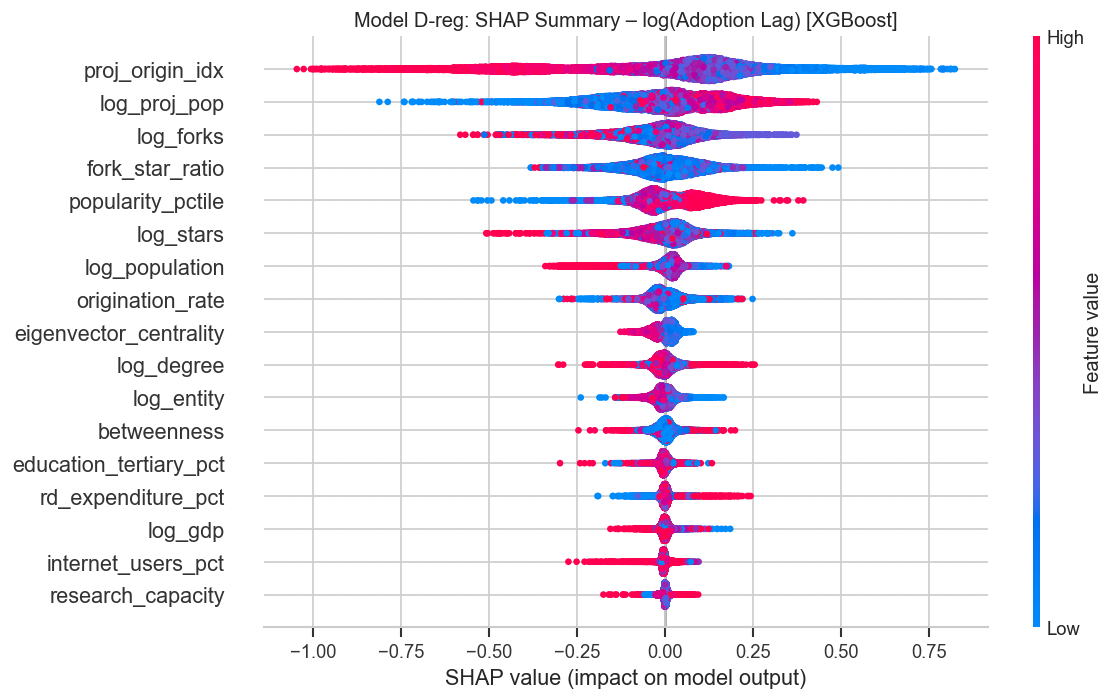


Interpretation:
  Project attributes and aggregates usually rank high: adoption timing is
  strongly project-specific. City features add incremental signal; compare
  their SHAP ranks to Step 10 for consistency across methods.


In [3]:
# --- Model D-reg: XGBoost regression on adoption lag (event-level) ---

y_raw = df_lag['lag'].values

y_lag = np.log1p(y_raw)

print(f'Non-originator adoption events (lag > 0): {len(df_lag)}')

print(f'Lag (raw):  mean={y_raw.mean():.2f}, median={np.median(y_raw):.0f}, '

      f'std={y_raw.std():.2f}, skew={pd.Series(y_raw).skew():.2f}')

print(f'Lag (log):  mean={y_lag.mean():.2f}, std={y_lag.std():.2f}, '

      f'skew={pd.Series(y_lag).skew():.2f}')

print(f'\nFeatures ({len(DREG_COLS)}): {DREG_COLS}')



X_lag = df_lag[DREG_COLS].values



xgb_lag = XGBRegressor(

    n_estimators=1000, max_depth=6, learning_rate=0.03,

    subsample=0.8, colsample_bytree=0.8,

    reg_lambda=1.0, random_state=42,

    tree_method='hist', verbosity=0,

)



cv_lag = KFold(n_splits=5, shuffle=True, random_state=42)

cv_r2_lag = cross_val_score(xgb_lag, X_lag, y_lag, cv=cv_lag, scoring='r2')

print(f'\nModel D-reg CV R² (log-lag, XGBoost): {cv_r2_lag.mean():.4f} ± {cv_r2_lag.std():.4f}')

for i, s in enumerate(cv_r2_lag):

    print(f'  Fold {i+1}: R² = {s:.4f}')



xgb_lag.fit(X_lag, y_lag)

y_pred_log = xgb_lag.predict(X_lag)

print(f'\nFull-data R² (log-lag)  = {r2_score(y_lag, y_pred_log):.4f}')

print(f'Full-data RMSE (log-lag) = {np.sqrt(mean_squared_error(y_lag, y_pred_log)):.4f}')



y_pred_raw = np.expm1(y_pred_log)

print(f'Full-data R² (raw lag)  = {r2_score(y_raw, y_pred_raw):.4f}')

print(f'Full-data RMSE (raw lag) = {np.sqrt(mean_squared_error(y_raw, y_pred_raw)):.2f} months')



# SHAP (TreeExplainer supports XGBoost)

explainer_lag = shap.TreeExplainer(xgb_lag)

shap_values_lag = explainer_lag.shap_values(X_lag)



mean_shap_lag = np.abs(shap_values_lag).mean(0)

top_lag = np.argsort(-mean_shap_lag)

print(f'\nSHAP feature importance (Model D-reg):')

for i in top_lag:

    print(f'  {DREG_COLS[i]:30s}  mean|SHAP| = {mean_shap_lag[i]:.4f}')



fig, ax = plt.subplots(figsize=(10, 6))

shap.summary_plot(shap_values_lag, X_lag, feature_names=DREG_COLS,

                  show=False, plot_size=None)

plt.title('Model D-reg: SHAP Summary – log(Adoption Lag) [XGBoost]', fontsize=12)

plt.tight_layout()

plt.show()



print('\nInterpretation:')

print('  Project attributes and aggregates usually rank high: adoption timing is')

print('  strongly project-specific. City features add incremental signal; compare')

print('  their SHAP ranks to Step 10 for consistency across methods.')


---
## 11.2 – Sensitivity: Inter-Event Interval (IEI)

**Motivation:** Model D-reg uses `log1p(lag)` (months from project *creation* to city
adoption) as the DV. This mechanically correlates with project age — older projects
accumulate larger possible lags. To test whether SHAP feature rankings are robust to
this artefact, we replace the DV with **inter-event interval (IEI)**: the time gap
between *consecutive* city adoptions within the same project's diffusion sequence.

| Event | IEI definition |
|---|---|
| First adopter (originator) | `t₁ − t_creation` (= lag; excluded when lag = 0) |
| Subsequent adopters | `tᵢ − tᵢ₋₁` (months since the *previous* city adopted) |

IEI measures **local diffusion pace per step**, largely decoupled from project age.
Same 17 features and same XGBoost specification as Model D-reg; only the DV changes.

IEI events (lag > 0): 25297
  interval = 0 (same month as prev city): 7922
  interval > 0: 17375
Interval (raw):  mean=2.64, median=1, std=4.42
Interval (log):  mean=0.89, std=0.82



Model D-reg-IEI CV R² (log-interval): 0.3072 ± 0.0122
  Fold 1: R² = 0.3051
  Fold 2: R² = 0.3063
  Fold 3: R² = 0.3290
  Fold 4: R² = 0.2910
  Fold 5: R² = 0.3045



Full-data R² (log-interval)  = 0.5768
Full-data RMSE (log-interval) = 0.5353



SHAP feature importance (Model D-reg-IEI):
  log_proj_pop                    mean|SHAP| = 0.3100
  proj_origin_idx                 mean|SHAP| = 0.1534
  popularity_pctile               mean|SHAP| = 0.0619
  log_forks                       mean|SHAP| = 0.0530
  log_stars                       mean|SHAP| = 0.0458
  betweenness                     mean|SHAP| = 0.0438
  origination_rate                mean|SHAP| = 0.0404
  fork_star_ratio                 mean|SHAP| = 0.0358
  log_population                  mean|SHAP| = 0.0349
  log_entity                      mean|SHAP| = 0.0280
  log_degree                      mean|SHAP| = 0.0238
  education_tertiary_pct          mean|SHAP| = 0.0152
  rd_expenditure_pct              mean|SHAP| = 0.0130
  eigenvector_centrality          mean|SHAP| = 0.0112
  log_gdp                         mean|SHAP| = 0.0077
  research_capacity               mean|SHAP| = 0.0073
  internet_users_pct              mean|SHAP| = 0.0065


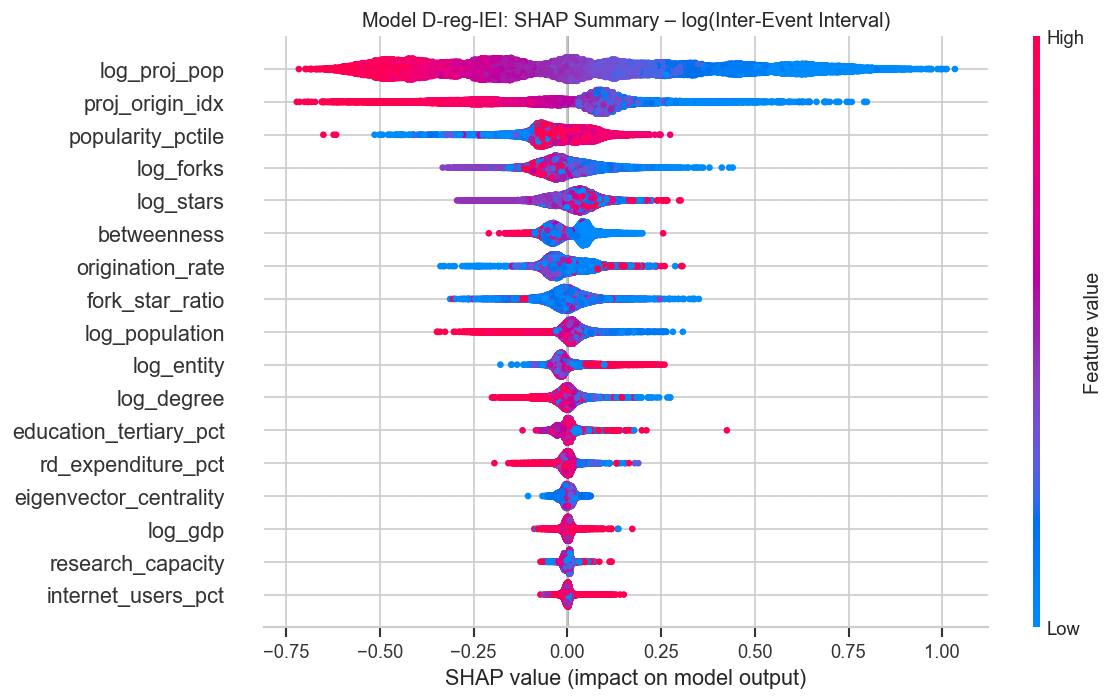


SHAP RANKING COMPARISON: log(lag) vs log(IEI)
  Feature                          lag   IEI     Δ
  ------------------------------  ----  ----  ----
  log_degree                        10    11    +1
  log_population                     7     9    +2
  log_gdp                           15    15    +0
  log_entity                        11    10    -1
  education_tertiary_pct            13    12    -1
  internet_users_pct                16    17    +1
  rd_expenditure_pct                14    13    -1
  research_capacity                 17    16    -1
  betweenness                       12     6    -6
  eigenvector_centrality             9    14    +5
  origination_rate                   8     7    -1
  log_proj_pop                       2     1    -1
  proj_origin_idx                    1     2    +1
  log_stars                          6     5    -1
  log_forks                          3     4    +1
  popularity_pctile                  5     3    -2
  fork_star_ratio                  

In [4]:
# --- Model D-reg-IEI: Inter-Event Interval as DV ---

df_cp['_adopt_idx'] = df_cp['city_first_adoption_month'].apply(_ym_to_months)
df_cp = df_cp.sort_values(['project_id', '_adopt_idx', 'city']).reset_index(drop=True)
df_cp['_prev_adopt'] = df_cp.groupby('project_id')['_adopt_idx'].shift(1)
df_cp['interval'] = df_cp['_adopt_idx'] - df_cp['_prev_adopt'].fillna(
    df_cp['proj_origin_idx'])

df_iei = df_cp[df_cp['lag'] > 0].copy()
for c in PROJ_ATTR_COLS:
    df_iei[c] = df_iei[c].fillna(df_iei[c].median())

y_iei_raw = df_iei['interval'].values.astype(float)
y_iei = np.log1p(np.clip(y_iei_raw, 0, None))

print(f'IEI events (lag > 0): {len(df_iei)}')
print(f'  interval = 0 (same month as prev city): {(y_iei_raw == 0).sum()}')
print(f'  interval > 0: {(y_iei_raw > 0).sum()}')
print(f'Interval (raw):  mean={y_iei_raw.mean():.2f}, median={np.median(y_iei_raw):.0f}, '
      f'std={y_iei_raw.std():.2f}')
print(f'Interval (log):  mean={y_iei.mean():.2f}, std={y_iei.std():.2f}')

X_iei = df_iei[DREG_COLS].values

xgb_iei = XGBRegressor(
    n_estimators=1000, max_depth=6, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.8,
    reg_lambda=1.0, random_state=42,
    tree_method='hist', verbosity=0,
)

cv_iei = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2_iei = cross_val_score(xgb_iei, X_iei, y_iei, cv=cv_iei, scoring='r2')
print(f'\nModel D-reg-IEI CV R² (log-interval): {cv_r2_iei.mean():.4f} ± {cv_r2_iei.std():.4f}')
for i, s in enumerate(cv_r2_iei):
    print(f'  Fold {i+1}: R² = {s:.4f}')

xgb_iei.fit(X_iei, y_iei)
y_pred_iei = xgb_iei.predict(X_iei)
print(f'\nFull-data R² (log-interval)  = {r2_score(y_iei, y_pred_iei):.4f}')
print(f'Full-data RMSE (log-interval) = {np.sqrt(mean_squared_error(y_iei, y_pred_iei)):.4f}')

explainer_iei = shap.TreeExplainer(xgb_iei)
shap_values_iei = explainer_iei.shap_values(X_iei)
mean_shap_iei = np.abs(shap_values_iei).mean(0)
top_iei = np.argsort(-mean_shap_iei)

print(f'\nSHAP feature importance (Model D-reg-IEI):')
for i in top_iei:
    print(f'  {DREG_COLS[i]:30s}  mean|SHAP| = {mean_shap_iei[i]:.4f}')

fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values_iei, X_iei, feature_names=DREG_COLS,
                  show=False, plot_size=None)
plt.title('Model D-reg-IEI: SHAP Summary – log(Inter-Event Interval)', fontsize=12)
plt.tight_layout()
plt.savefig(str(DATA / 'shap_dreg_iei_summary.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- SHAP ranking comparison ---
print('\n' + '=' * 70)
print('SHAP RANKING COMPARISON: log(lag) vs log(IEI)')
print('=' * 70)
rank_lag = {DREG_COLS[i]: r+1 for r, i in enumerate(np.argsort(-mean_shap_lag))}
rank_iei_d = {DREG_COLS[i]: r+1 for r, i in enumerate(top_iei)}
print(f'  {"Feature":30s}  {"lag":>4s}  {"IEI":>4s}  {"Δ":>4s}')
print(f'  {"-"*30}  {"----":>4s}  {"----":>4s}  {"----":>4s}')
for f in DREG_COLS:
    rl, ri = rank_lag[f], rank_iei_d[f]
    print(f'  {f:30s}  {rl:4d}  {ri:4d}  {ri-rl:+4d}')
print()
print('If proj_origin_idx drops markedly in the IEI ranking, it confirms that')
print('its dominance in the lag model was partly driven by project-age correlation.')

---
## 11.2b – Sensitivity: Removing Project-Aggregate Features

`log_proj_pop` (number of adopting cities) and `proj_origin_idx` (project creation time)
are the top-2 SHAP features in both lag and IEI models. Both carry potential confounds:

- **`proj_origin_idx`**: mechanically correlated with lag (older projects → longer
  possible lags) and may capture cohort / observation-window effects.
- **`log_proj_pop`**: post-hoc measure (total adopting cities is an outcome, not a
  pre-diffusion characteristic).

Below we re-run both DV specifications (lag and IEI) with **15 features** (dropping these
two), then compare all four SHAP rankings side by side.

15-feature set: ['log_degree', 'log_population', 'log_gdp', 'log_entity', 'education_tertiary_pct', 'internet_users_pct', 'rd_expenditure_pct', 'research_capacity', 'betweenness', 'eigenvector_centrality', 'origination_rate', 'log_stars', 'log_forks', 'popularity_pctile', 'fork_star_ratio']



Model lag×15  CV R²: 0.1927 ± 0.0075
  log_forks                       mean|SHAP| = 0.1019
  fork_star_ratio                 mean|SHAP| = 0.1019
  popularity_pctile               mean|SHAP| = 0.0958
  log_stars                       mean|SHAP| = 0.0689
  eigenvector_centrality          mean|SHAP| = 0.0379
  log_population                  mean|SHAP| = 0.0303
  origination_rate                mean|SHAP| = 0.0238
  log_entity                      mean|SHAP| = 0.0207
  betweenness                     mean|SHAP| = 0.0172
  log_degree                      mean|SHAP| = 0.0167
  rd_expenditure_pct              mean|SHAP| = 0.0123
  log_gdp                         mean|SHAP| = 0.0090
  education_tertiary_pct          mean|SHAP| = 0.0090
  internet_users_pct              mean|SHAP| = 0.0085
  research_capacity               mean|SHAP| = 0.0067


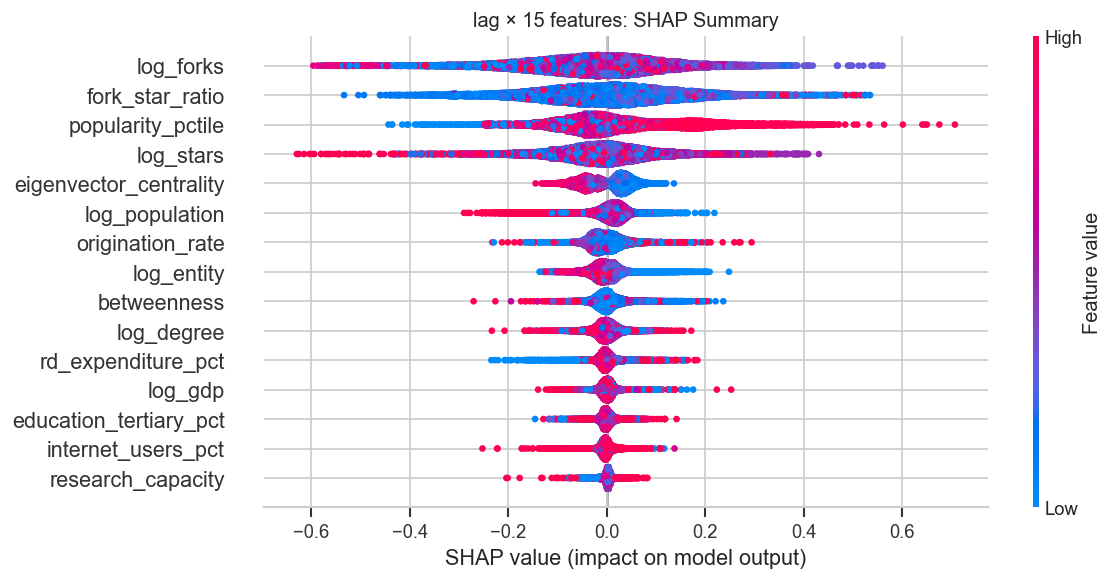


Model IEI×15  CV R²: 0.1808 ± 0.0114
  log_forks                       mean|SHAP| = 0.1893
  popularity_pctile               mean|SHAP| = 0.0839
  log_stars                       mean|SHAP| = 0.0836
  fork_star_ratio                 mean|SHAP| = 0.0759
  betweenness                     mean|SHAP| = 0.0401
  origination_rate                mean|SHAP| = 0.0355
  log_entity                      mean|SHAP| = 0.0332
  log_population                  mean|SHAP| = 0.0285
  education_tertiary_pct          mean|SHAP| = 0.0209
  log_degree                      mean|SHAP| = 0.0203
  rd_expenditure_pct              mean|SHAP| = 0.0122
  eigenvector_centrality          mean|SHAP| = 0.0118
  log_gdp                         mean|SHAP| = 0.0093
  research_capacity               mean|SHAP| = 0.0080
  internet_users_pct              mean|SHAP| = 0.0064


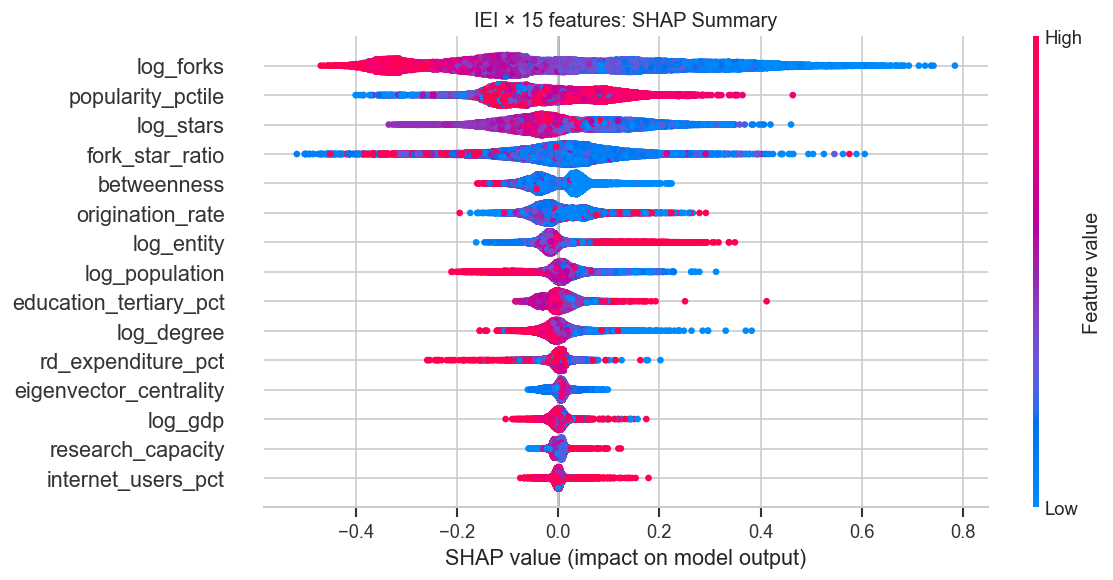


4-WAY SHAP RANKING COMPARISON
  Feature                         lag17  IEI17  lag15  IEI15
  ------------------------------  -----  -----  -----  -----
  log_degree                         10     11     10     10
  log_population                      7      9      6      8
  log_gdp                            15     15     12     13
  log_entity                         11     10      8      7
  education_tertiary_pct             13     12     13      9
  internet_users_pct                 16     17     14     15
  rd_expenditure_pct                 14     13     11     11
  research_capacity                  17     16     15     14
  betweenness                        12      6      9      5
  eigenvector_centrality              9     14      5     12
  origination_rate                    8      7      7      6
  log_proj_pop                        2      1      —      —
  proj_origin_idx                     1      2      —      —
  log_stars                           6      5      4 

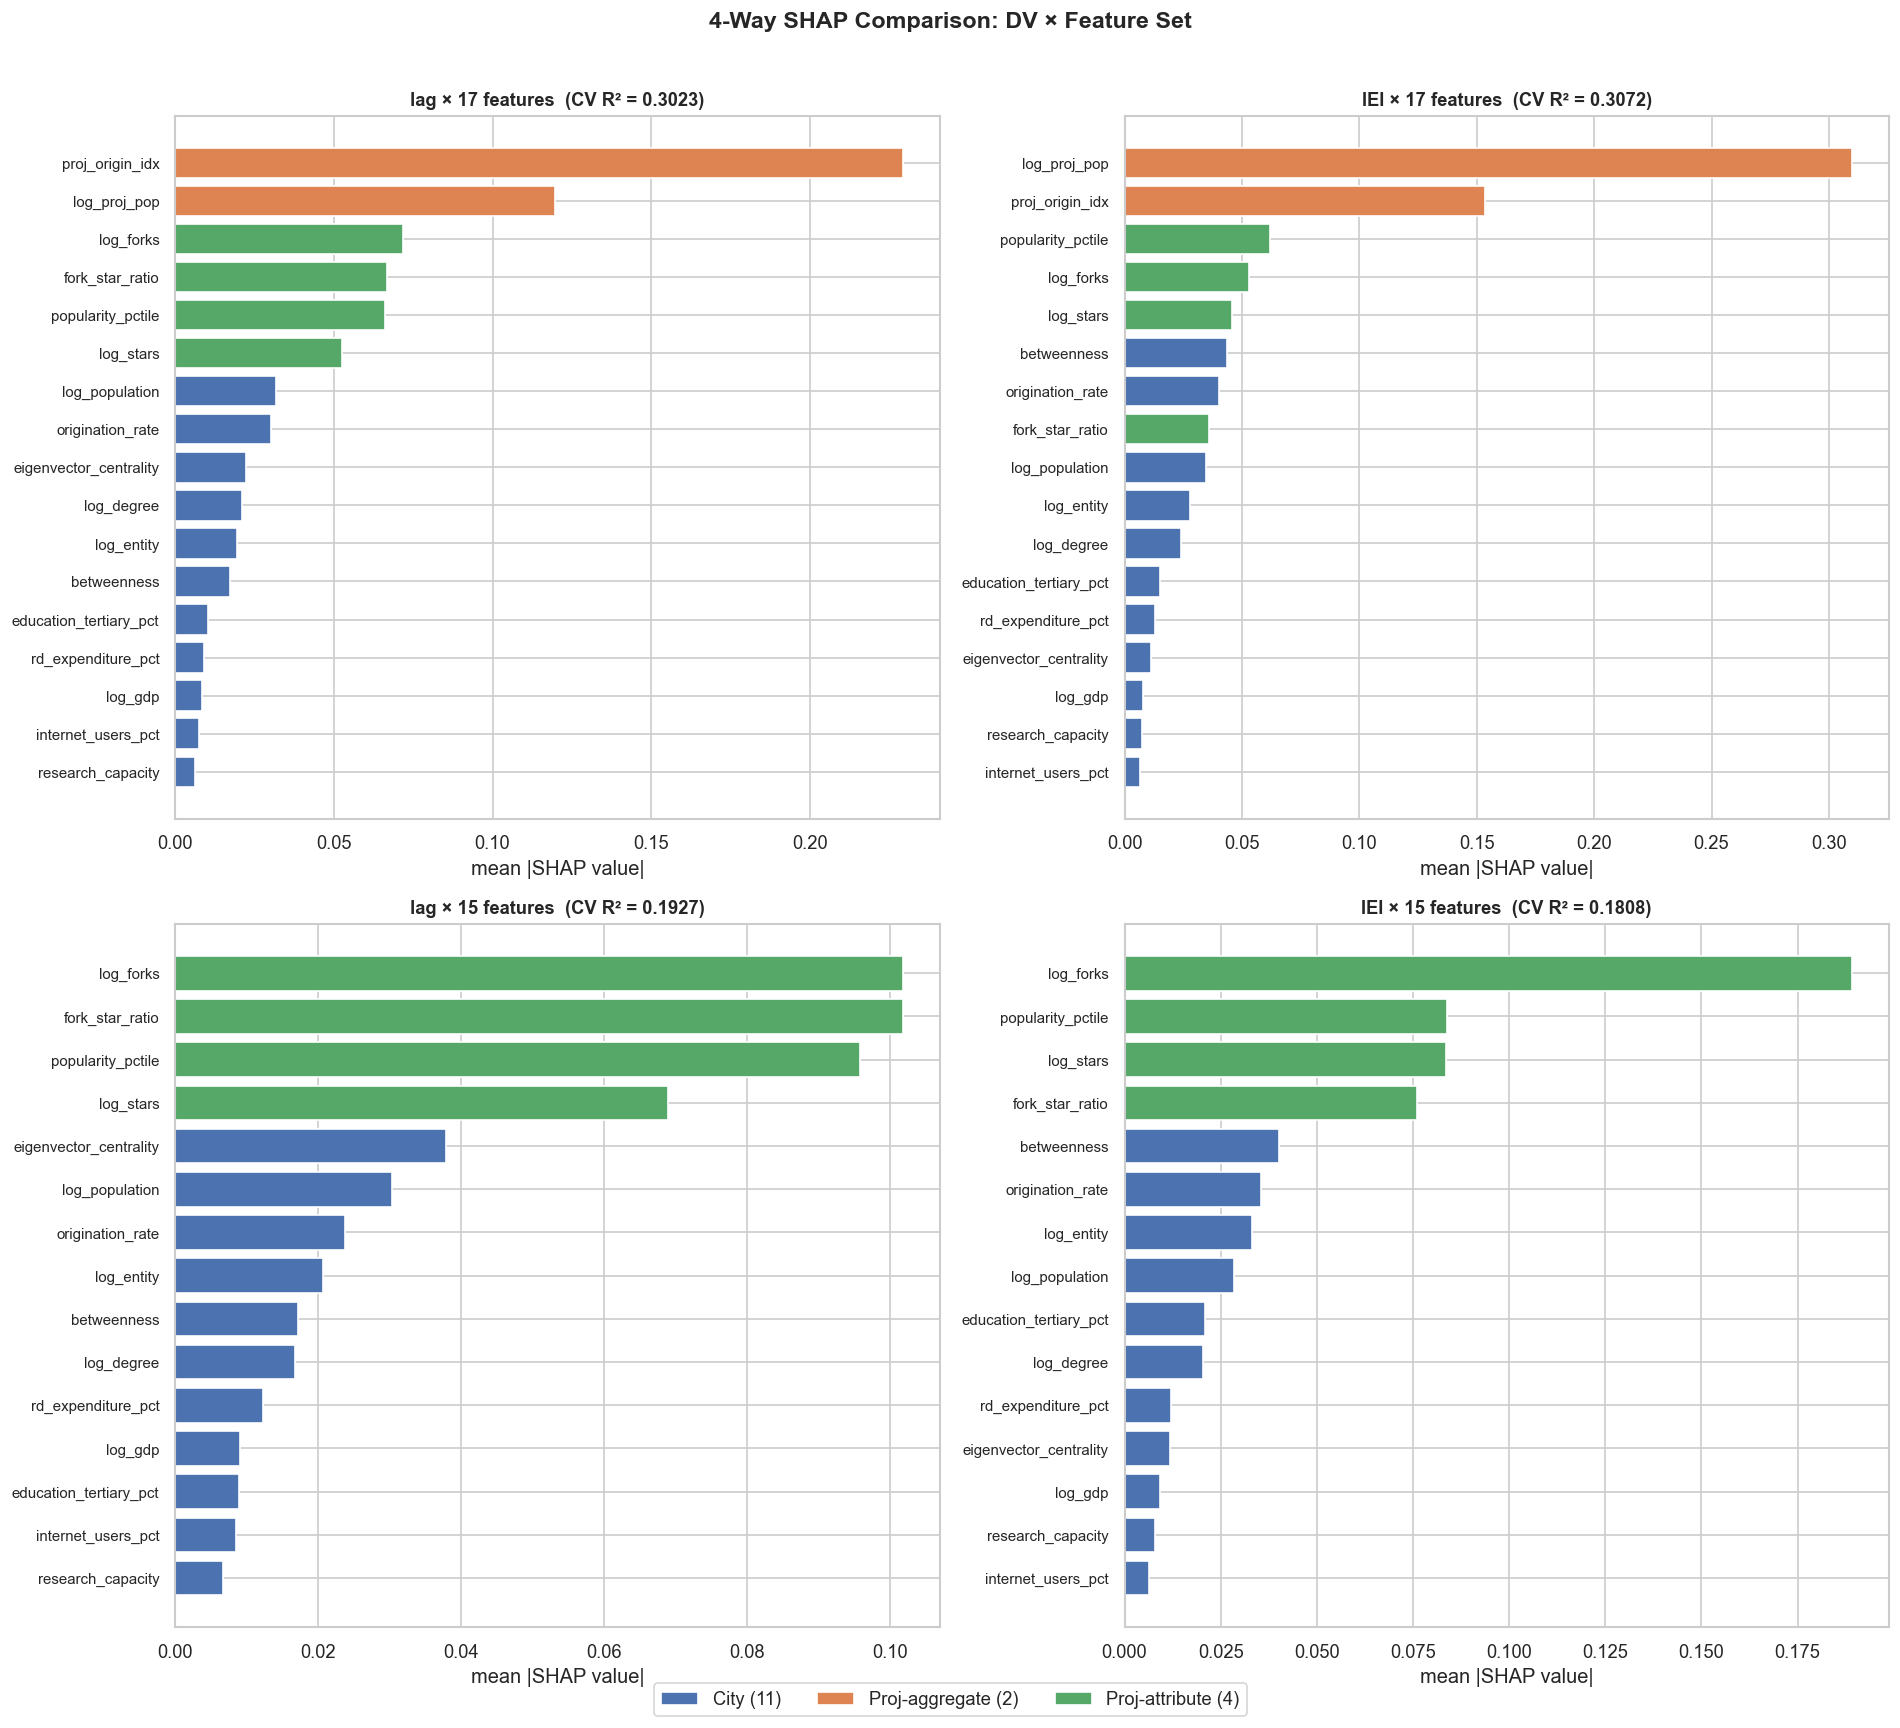

In [5]:
# --- 15-feature models: drop log_proj_pop & proj_origin_idx ---

DREG15 = [c for c in DREG_COLS if c not in ('log_proj_pop', 'proj_origin_idx')]
print(f'15-feature set: {DREG15}\n')

xgb_params = dict(
    n_estimators=1000, max_depth=6, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.8,
    reg_lambda=1.0, random_state=42,
    tree_method='hist', verbosity=0,
)
cv_spec = KFold(n_splits=5, shuffle=True, random_state=42)

# ---- (A) lag × 15 features ----
X_lag15 = df_lag[DREG15].values
y_lag15 = np.log1p(df_lag['lag'].values)

xgb_lag15 = XGBRegressor(**xgb_params)
cv_r2_lag15 = cross_val_score(xgb_lag15, X_lag15, y_lag15, cv=cv_spec, scoring='r2')
xgb_lag15.fit(X_lag15, y_lag15)

exp_lag15 = shap.TreeExplainer(xgb_lag15)
sv_lag15 = exp_lag15.shap_values(X_lag15)
ms_lag15 = np.abs(sv_lag15).mean(0)

print(f'Model lag×15  CV R²: {cv_r2_lag15.mean():.4f} ± {cv_r2_lag15.std():.4f}')
for i in np.argsort(-ms_lag15):
    print(f'  {DREG15[i]:30s}  mean|SHAP| = {ms_lag15[i]:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
shap.summary_plot(sv_lag15, X_lag15, feature_names=DREG15, show=False, plot_size=None)
plt.title('lag × 15 features: SHAP Summary', fontsize=12)
plt.tight_layout()
plt.savefig(str(DATA / 'shap_lag15_summary.png'), dpi=150, bbox_inches='tight')
plt.show()

# ---- (B) IEI × 15 features ----
X_iei15 = df_iei[DREG15].values

xgb_iei15 = XGBRegressor(**xgb_params)
cv_r2_iei15 = cross_val_score(xgb_iei15, X_iei15, y_iei, cv=cv_spec, scoring='r2')
xgb_iei15.fit(X_iei15, y_iei)

exp_iei15 = shap.TreeExplainer(xgb_iei15)
sv_iei15 = exp_iei15.shap_values(X_iei15)
ms_iei15 = np.abs(sv_iei15).mean(0)

print(f'\nModel IEI×15  CV R²: {cv_r2_iei15.mean():.4f} ± {cv_r2_iei15.std():.4f}')
for i in np.argsort(-ms_iei15):
    print(f'  {DREG15[i]:30s}  mean|SHAP| = {ms_iei15[i]:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
shap.summary_plot(sv_iei15, X_iei15, feature_names=DREG15, show=False, plot_size=None)
plt.title('IEI × 15 features: SHAP Summary', fontsize=12)
plt.tight_layout()
plt.savefig(str(DATA / 'shap_iei15_summary.png'), dpi=150, bbox_inches='tight')
plt.show()

# ---- 4-way comparison table ----
def _rank(ms, cols):
    return {cols[i]: r+1 for r, i in enumerate(np.argsort(-ms))}

r17_lag = _rank(mean_shap_lag, DREG_COLS)
r17_iei = _rank(mean_shap_iei, DREG_COLS)
r15_lag = _rank(ms_lag15, DREG15)
r15_iei = _rank(ms_iei15, DREG15)

print('\n' + '=' * 78)
print('4-WAY SHAP RANKING COMPARISON')
print('=' * 78)
print(f'  {"Feature":30s}  {"lag17":>5s}  {"IEI17":>5s}  {"lag15":>5s}  {"IEI15":>5s}')
print(f'  {"-"*30}  {"-----":>5s}  {"-----":>5s}  {"-----":>5s}  {"-----":>5s}')
for f in DREG_COLS:
    c1 = f'{r17_lag[f]:5d}'
    c2 = f'{r17_iei[f]:5d}'
    c3 = f'{r15_lag.get(f, "—"):>5}' if f in r15_lag else '    —'
    c4 = f'{r15_iei.get(f, "—"):>5}' if f in r15_iei else '    —'
    print(f'  {f:30s}  {c1}  {c2}  {c3}  {c4}')

print(f'\n  CV R² summary:')
print(f'    lag×17 : {cv_r2_lag.mean():.4f}    IEI×17 : {cv_r2_iei.mean():.4f}')
print(f'    lag×15 : {cv_r2_lag15.mean():.4f}    IEI×15 : {cv_r2_iei15.mean():.4f}')
r2_drop_lag = cv_r2_lag.mean() - cv_r2_lag15.mean()
r2_drop_iei = cv_r2_iei.mean() - cv_r2_iei15.mean()
print(f'    R² drop from 17→15:  lag {r2_drop_lag:+.4f},  IEI {r2_drop_iei:+.4f}')

# ---- 2×2 SHAP bar chart (mean |SHAP|) ----
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

configs = [
    (mean_shap_lag, DREG_COLS, cv_r2_lag.mean(), 'lag × 17 features', axes[0, 0]),
    (mean_shap_iei, DREG_COLS, cv_r2_iei.mean(), 'IEI × 17 features', axes[0, 1]),
    (ms_lag15, DREG15, cv_r2_lag15.mean(), 'lag × 15 features', axes[1, 0]),
    (ms_iei15, DREG15, cv_r2_iei15.mean(), 'IEI × 15 features', axes[1, 1]),
]

for ms, cols, r2, title, ax in configs:
    order = np.argsort(ms)
    cols_sorted = [cols[i] for i in order]
    vals_sorted = ms[order]

    colors = []
    city_set = set(IV_COLS + EXTRA_CITY_COLS)
    for c in cols_sorted:
        if c in city_set:
            colors.append('#4C72B0')
        elif c in ('log_proj_pop', 'proj_origin_idx'):
            colors.append('#DD8452')
        else:
            colors.append('#55A868')

    ax.barh(range(len(cols_sorted)), vals_sorted, color=colors)
    ax.set_yticks(range(len(cols_sorted)))
    ax.set_yticklabels(cols_sorted, fontsize=9)
    ax.set_xlabel('mean |SHAP value|')
    ax.set_title(f'{title}  (CV R² = {r2:.4f})', fontsize=11, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4C72B0', label='City (11)'),
    Patch(facecolor='#DD8452', label='Proj-aggregate (2)'),
    Patch(facecolor='#55A868', label='Proj-attribute (4)'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=11,
           bbox_to_anchor=(0.5, -0.01))
fig.suptitle('4-Way SHAP Comparison: DV × Feature Set', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(str(DATA / 'shap_4way_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 11.4 – Discussion: Event-Level Modelling and R²

### What this model is

Model D-reg is estimated at the **city–project** (adoption **event**) level (n ≈ 25k),
not at the city cross-section (n = 148). City-level covariates are **repeated** across
all events for that city; to explain event-level variance in lag, **project-varying**
predictors (stars, forks, popularity percentile, etc.) are necessary.

### Typical R² and feature roles

With **11 city + 6 project** predictors and `log1p(lag)`, cross-validated R² is typically
**≈ 0.30** (exact value depends on fold & seed). That is a **moderate** fit: most residual
variance reflects idiosyncratic timing not captured by observable city/project scalars.

SHAP orders features **within the variance the model does explain**; a moderate R² does not
invalidate ranking *if* CV R² is clearly above zero and the specification is pre-specified.

### Limitations

| Limitation | Note |
|---|---|
| **Within-city dependence** | Many events per city; KFold may be optimistic vs GroupKFold-by-city. |
| **Project metrics timing** | Popularity metrics are contemporaneous / post-hoc; interpret as association, not causal instruments. |
| **HF fork_star** | HuggingFace rows lack fork_star_ratio; filled via median imputation for those events. |

### Alignment with Step 10

Top **city** predictors in SHAP should be read alongside Step 10 coefficients; stable
ranking of e.g. `log_entity`, `log_degree` across linear and tree models strengthens
interpretive confidence.


---
## 11.5 – Summary


In [6]:
print('=' * 70)

print('STEP 11 SUMMARY: XGBOOST + SHAP')

print('=' * 70)

print()



print('MODEL PERFORMANCE')

print('-' * 70)

print(f'  Model D-reg (XGBoost, log(adoption lag), n={len(df_lag):,})')

print(f'    CV R2 (log-lag): {cv_r2_lag.mean():.4f} +/- {cv_r2_lag.std():.4f}')

print(f'    Features: {len(DREG_COLS)} ({len(IV_COLS)} city-base'

      f' + {len(EXTRA_CITY_COLS)} city-extra + 2 proj-agg + {len(PROJ_ATTR_COLS)} proj-attr)')

print()



print('FEATURE IMPORTANCE (SHAP)')

print('-' * 70)

top5_lag = [DREG_COLS[i] for i in np.argsort(-mean_shap_lag)[:5]]

print(f'  Model D-reg     top-5: {", ".join(top5_lag)}')

top5_iei = [DREG_COLS[i] for i in np.argsort(-mean_shap_iei)[:5]]

print(f'  Model D-reg-IEI top-5: {", ".join(top5_iei)}')

print()



print('KEY CONCLUSIONS')

print('-' * 70)

print('  1. Event-level D-reg uses XGBoost + project-varying attributes; CV R² ~0.30 is')

print('     typical — most timing variance is project- and idiosyncrasy-driven.')

print()

print('  2. SHAP ranks city vs project contributions within the explained variance;')

print('     compare city block to Step 10 for cross-method robustness.')

print()

print('  3. For strict clustering-aware inference, consider GroupKFold by city.')


STEP 11 SUMMARY: XGBOOST + SHAP

MODEL PERFORMANCE
----------------------------------------------------------------------
  Model D-reg (XGBoost, log(adoption lag), n=25,297)
    CV R2 (log-lag): 0.3023 +/- 0.0160
    Features: 17 (9 city-base + 2 city-extra + 2 proj-agg + 4 proj-attr)

FEATURE IMPORTANCE (SHAP)
----------------------------------------------------------------------
  Model D-reg     top-5: proj_origin_idx, log_proj_pop, log_forks, fork_star_ratio, popularity_pctile
  Model D-reg-IEI top-5: log_proj_pop, proj_origin_idx, popularity_pctile, log_forks, log_stars

KEY CONCLUSIONS
----------------------------------------------------------------------
  1. Event-level D-reg uses XGBoost + project-varying attributes; CV R² ~0.30 is
     typical — most timing variance is project- and idiosyncrasy-driven.

  2. SHAP ranks city vs project contributions within the explained variance;
     compare city block to Step 10 for cross-method robustness.

  3. For strict clustering-aware